In [117]:
import sys
print(sys.executable)
!pip install ucimlrepo

/Users/alya57/venvs/myenv/bin/python

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Using random_state = 1761682091
Train samples: 16512
Test samples: 4128
Shapes w/ intercept: (16512, 9) (4128, 9)
Bootstrap 1 shape: X=(16512, 9), y=(16512,)
Bootstrap 2 shape: X=(16512, 9), y=(16512,)
Bootstrap 3 shape: X=(16512, 9), y=(16512,)


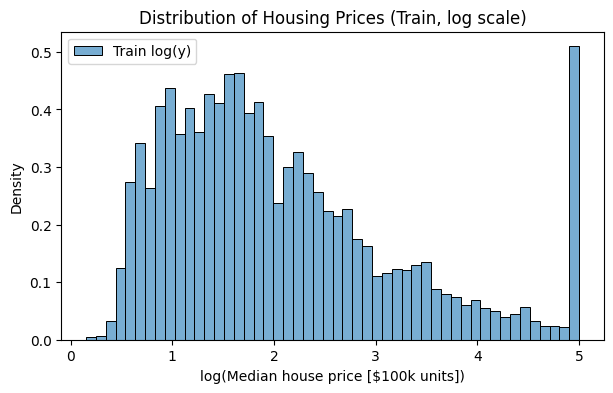

5.00001
0.14238760541615186


In [118]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

california = fetch_california_housing(as_frame=False) 
X = california.data          
y = california.target        

import time
seed = int(time.time())
print("Using random_state =", seed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=seed
)
#y_train = np.log(y_train)
#y_test  = np.log(y_test)
print("Train samples:", len(y_train))
print("Test samples:", len(y_test))
def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train = add_intercept(X_train)
X_test  = add_intercept(X_test)

print("Shapes w/ intercept:", X_train.shape, X_test.shape)

n_bootstraps = 3
n_train = len(y_train)

base_ss = np.random.SeedSequence()
child_ss = base_ss.spawn(n_bootstraps)

bootstraps = []
for b, ss in enumerate(child_ss, start=1):
    rng = np.random.default_rng(ss)
    idx = rng.integers(0, n_train, size=n_train, endpoint=False)
    X_bs = X_train[idx]
    y_bs = y_train[idx]
    bootstraps.append((X_bs, y_bs))
    print(f"Bootstrap {b} shape: X={X_bs.shape}, y={y_bs.shape}")
plt.figure(figsize=(7,4))
sns.histplot(y_train, bins=50, stat="density", alpha=0.6, label="Train log(y)")
plt.title("Distribution of Housing Prices (Train, log scale)")
plt.xlabel("log(Median house price [$100k units])")
plt.ylabel("Density")
plt.legend()
plt.show()
y_max = max(y)
print(y_max)
print(np.log(y_train.std()))
X_train_np = X_train
X_test_np  = X_test
y_train_np = y_train
y_test_np  = y_test



In [119]:
#y_log = np.log(y_train)
#y_log_c = y_log - y_log.mean()

X_std = (X_train[:,1:] - X_train[:,1:].mean(0)) / X_train[:,1:].std(0)
X_proc = np.column_stack([np.ones(len(y_log)), X_std])
prior_mean_beta = np.zeros(X_proc.shape[1], dtype=np.float32)
prior_std_beta  = np.ones(X_proc.shape[1], dtype=np.float32)
prior_mean_logsig = 0
prior_std_logsig  = 0.5    





In [120]:
import torch
import torch.nn as nn
import torch.optim as optim
BATCH_SIZE = 128
MC_SAMPLES = 100
STEPS      = 1000
LR         = 1e-3
SEED       = 123

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Running deterministically with SEED={SEED}")

class VariationalLinearRegression(nn.Module):
    def __init__(self, n_features, init_m_beta=None, init_log_s_beta=-2.0,
                 init_m_log_sigma2=0.0, init_log_s_log_sigma2=-2.0, device="cpu"):
        super().__init__()
        
        if init_m_beta is None:
            init_m_beta = np.zeros(n_features)
        self.m_beta     = nn.Parameter(torch.tensor(init_m_beta, dtype=torch.float32, device=device))
        self.log_s_beta = nn.Parameter(torch.ones(n_features, device=device) * init_log_s_beta)

        self.m_logsig     = nn.Parameter(torch.tensor(float(init_m_log_sigma2), device=device))
        self.log_s_logsig = nn.Parameter(torch.tensor(float(init_log_s_log_sigma2), device=device))

    def sample_beta(self, num_samples=1):
        eps = torch.randn((num_samples, len(self.m_beta)), device=self.m_beta.device)
        return self.m_beta + torch.exp(self.log_s_beta) * eps

    def sample_sigma2(self, num_samples=1, sigma_min=0.1):
        """
        Draw posterior samples of σ².
        We use a floor (sigma_min) to prevent collapse when beta < 1.
        """
        eps = torch.randn(num_samples, device=self.m_logsig.device)
        log_sigma2 = self.m_logsig + torch.exp(self.log_s_logsig) * eps

        # map to positive sigma2
        sigma2 = torch.exp(log_sigma2)

        # apply floor in sigma (not sigma²)
        sigma = torch.sqrt(sigma2)
        sigma = torch.nn.functional.softplus(sigma) + sigma_min
        return sigma ** 2


    def kl_divergence_beta(self, prior_mean, prior_std):
        q_var = torch.exp(2 * self.log_s_beta)   # variance
        tau2  = prior_std**2
        kl = 0.5 * ( (q_var + (self.m_beta - prior_mean)**2) / tau2
                     - 1.0 + torch.log(tau2 / q_var) )
        return kl.sum()

    def kl_divergence_sigma2(self, prior_mean, prior_std):
        q_var = torch.exp(2 * self.log_s_logsig)
        tau2  = prior_std**2
        kl = 0.5 * ( (q_var + (self.m_logsig - prior_mean)**2) / tau2
                     - 1.0 + torch.log(tau2 / q_var) )
        return kl


Running deterministically with SEED=123


In [121]:
import torch

def nll_loss_regression(X, y, beta, sigma2):
    """
    Negative log-likelihood for Gaussian regression:
    y ~ N(Xβ, σ²)
    Returns SUM over samples.
    """
    mu = X @ beta
    dist = torch.distributions.Normal(mu, sigma2.sqrt())
    return -dist.log_prob(y).sum()


def beta_loss_regression(X, y, beta_params, sigma2, beta_div):
    """
    β-loss (beta divergence objective for Gaussian regression).
    Returns SUM over samples.
    """
    sigma2 = torch.clamp(sigma2, min=1e-6)
    mu = X @ beta_params
    log_px = -0.5 * (y - mu) ** 2 / sigma2 - 0.5 * torch.log(2 * torch.pi * sigma2)

    # f(y)^(β-1), stabilized
    log_f = (beta_div - 1.0) * log_px
    max_log = torch.max(log_f)
    f_beta_minus1 = torch.exp(log_f - max_log)

    # first term (sum)
    first_term = -(1.0 / (beta_div - 1.0)) * (f_beta_minus1.sum() * torch.exp(max_log))

    # integral term (closed form for Gaussian)
    integral = (2 * torch.pi * sigma2) ** ((1.0 - beta_div) / 2.0) * (beta_div ** -0.5)
    second_term = (y.numel() / beta_div) * integral

    return first_term + second_term


def gamma_loss_regression(X, y, beta, sigma2, gamma):
    """
    γ-loss (gamma divergence objective for Gaussian regression).
    Returns SUM over samples.
    """
    sigma2 = torch.clamp(sigma2, min=1e-6)
    mu = X @ beta
    log_px = -0.5 * (y - mu) ** 2 / sigma2 - 0.5 * torch.log(2 * torch.pi * sigma2)

    # p(y|x, θ)^γ
    px_gamma = torch.exp(gamma * log_px)

    # first term: (1/γ) * sum p(y)^γ
    likelihood_term = (1.0 / gamma) * px_gamma.sum()

    # second term: (n/(γ+1)) * ∫ p(y)^(1+γ) dy
    integral = (2 * torch.pi * sigma2) ** (-gamma / 2.0) * (1.0 + gamma) ** -0.5
    correction = (y.numel() / (gamma + 1.0)) * integral

    return -(likelihood_term - correction)



In [122]:
def divergence_kl(q,
                  prior_mean_beta,
                  prior_std_beta,
                  prior_mean_logsig,
                  prior_std_logsig):
    """
    KL divergence term for regression:
    q(β) vs N(prior_mean_beta, prior_std_beta^2)
    q(log σ²) vs N(prior_mean_logsig, prior_std_logsig^2)
    """
    device = q.m_beta.device

    kl_beta = q.kl_divergence_beta(
        prior_mean=torch.tensor(prior_mean_beta, dtype=torch.float32, device=device),
        prior_std=torch.tensor(prior_std_beta, dtype=torch.float32, device=device)
    )
    kl_sigma2 = q.kl_divergence_sigma2(
        prior_mean=torch.tensor(prior_mean_logsig, dtype=torch.float32, device=device),
        prior_std=torch.tensor(prior_std_logsig, dtype=torch.float32, device=device)
    )
    return kl_beta + kl_sigma2



In [123]:
from torch.utils.data import DataLoader, TensorDataset

def make_minibatches(X_numpy, y_numpy, batch_size=64, shuffle=True, device="cpu"):
    """
    Wrap numpy arrays into a DataLoader for minibatching.
    """
    X = torch.tensor(X_numpy, dtype=torch.float32, device=device)
    y = torch.tensor(y_numpy, dtype=torch.float32, device=device)
    ds = TensorDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, pin_memory=(device=="cuda"))


In [124]:
import torch
import torch.optim as optim
import numpy as np

def train_gvi_regression(
    X_numpy, y_numpy,
    loss_type="nll",            
    divergence_type="kl",      
    gamma=0.9, 
    beta = 1.1,                 
    steps=1000, lr=1e-3,
    batch_size=64, mc_samples=10,
    prior_mean_beta=None, prior_std_beta=None,
    prior_mean_logsig=None, prior_std_logsig=None,
    device="cpu"
):
    """
    Train variational inference for Bayesian linear regression (no scaling).
    X_numpy : (n, p)  [must already include intercept if you want one]
    y_numpy : (n,)
    """

    if hasattr(X_numpy, "values"): X_numpy = X_numpy.values
    if hasattr(y_numpy, "values"): y_numpy = y_numpy.values
    n, p = X_numpy.shape


    loader = make_minibatches(X_numpy, y_numpy, batch_size=batch_size, shuffle=True)
    q = VariationalLinearRegression(p, device=device)
    q.to(device)
    opt = optim.Adam(q.parameters(), lr=lr)

    if loss_type == "nll":
        loss_fn = lambda Xb, yb, b_s, s2_s: nll_loss_regression(Xb, yb, b_s, s2_s)
    elif loss_type == "beta":
        loss_fn = lambda Xb, yb, b_s, s2_s: beta_loss_regression(Xb, yb, b_s, s2_s, beta)
    elif loss_type == "gamma":

        loss_fn = lambda Xb, yb, b_s, s2_s: gamma_loss_regression(Xb, yb, b_s, s2_s, gamma)

    step = 0
    while step < steps:
        for Xb_cpu, yb_cpu in loader:
            Xb = Xb_cpu.to(device)
            yb = yb_cpu.to(device)

            opt.zero_grad()
            K = Xb.shape[0]
            mc_vals = []
            for _ in range(mc_samples):
                beta_s   = q.sample_beta(1).squeeze(0)   
                sigma2_s = q.sample_sigma2(1).squeeze(0)  
                ell_sum_batch = loss_fn(Xb, yb, beta_s, sigma2_s)   
                mc_vals.append((n / K) * ell_sum_batch)   
            data_term = torch.stack(mc_vals).mean()
            kl_beta = q.kl_divergence_beta(
                prior_mean=torch.tensor(prior_mean_beta, dtype=torch.float32, device=device),
                prior_std=torch.tensor(prior_std_beta,  dtype=torch.float32, device=device),
            )
            kl_sigma2 = q.kl_divergence_sigma2(
                prior_mean=torch.tensor(prior_mean_logsig, dtype=torch.float32, device=device),
                prior_std=torch.tensor(prior_std_logsig,  dtype=torch.float32, device=device),
            )
            reg_term = kl_beta + kl_sigma2
            obj = data_term + reg_term
            obj.backward()
            torch.nn.utils.clip_grad_norm_(q.parameters(), 1.0)

            opt.step()

            step += 1
            if step >= steps:
                break


    return q




In [125]:
import torch
import torch.optim as optim
def gaussian_kernel(x, y, sigma=1.0):
    """
    Gaussian RBF kernel between x and y.
    x: (n, d), y: (m, d)
    """
    x = x.unsqueeze(1)  
    y = y.unsqueeze(0) 
    dist_sq = torch.sum((x - y) ** 2, dim=2)
    return torch.exp(-dist_sq / (2 * sigma ** 2))

def mmd2(x_samples, y_samples, sigma=1.0, max_samples=1000):
    """
    Mini-batch estimate of MMD^2 between two sample sets.
    Subsamples if inputs are too large to avoid kernel blowup.
    """
    n = x_samples.size(0)
    m = y_samples.size(0)

    if n > max_samples:
        idx = torch.randint(0, n, (max_samples,), device=x_samples.device)
        x_samples = x_samples[idx]
        n = max_samples
    if m > max_samples:
        idx = torch.randint(0, m, (max_samples,), device=y_samples.device)
        y_samples = y_samples[idx]
        m = max_samples

    K_xx = gaussian_kernel(x_samples, x_samples, sigma)
    K_yy = gaussian_kernel(y_samples, y_samples, sigma)
    K_xy = gaussian_kernel(x_samples, y_samples, sigma)

    term_xx = (K_xx.sum() - torch.diag(K_xx).sum()) / (n * (n - 1))
    term_yy = (K_yy.sum() - torch.diag(K_yy).sum()) / (m * (m - 1))
    term_xy = 2 * K_xy.mean()

    return term_xx + term_yy - term_xy
def train_pcuq_regression(
    X_numpy, y_numpy,
    steps=1000, lr=1e-3, mc_samples=20,
    lambda_reg=1.0, mmd_sigma=1.0, mmd_max_samples=1000,
    prior_mean_beta=None, prior_std_beta=None,
    prior_mean_logsig=None, prior_std_logsig=None,
    device="cpu"
):
    """
    Train Bayesian linear regression with Prediction-Centric UQ (PCUQ).
    
    Args:
        X_numpy, y_numpy: training data
        mc_samples       : number of predictive samples
        lambda_reg       : weight for KL regularizer
        mmd_sigma        : bandwidth for Gaussian kernel
        mmd_max_samples  : cap sample size for MMD kernel (avoids O(N^2) blowup)
    Returns:
        q : trained variational posterior
    """
    if hasattr(X_numpy, "values"): X_numpy = X_numpy.values
    if hasattr(y_numpy, "values"): y_numpy = y_numpy.values

    X = torch.tensor(X_numpy, dtype=torch.float32, device=device)
    y = torch.tensor(y_numpy, dtype=torch.float32, device=device).view(-1,1)
    n, p = X.shape

    q = VariationalLinearRegression(p, device=device).to(device)
    opt = optim.Adam(q.parameters(), lr=lr)
    prior_mean_beta = torch.tensor(prior_mean_beta, dtype=torch.float32, device=device)
    prior_std_beta  = torch.tensor(prior_std_beta,  dtype=torch.float32, device=device)
    prior_mean_logsig = torch.tensor(prior_mean_logsig, dtype=torch.float32, device=device)
    prior_std_logsig  = torch.tensor(prior_std_logsig,  dtype=torch.float32, device=device)

    for step in range(steps):
        opt.zero_grad()
        betas   = q.sample_beta(mc_samples)        
        sigma2s = q.sample_sigma2(mc_samples)          
        means = X @ betas.T                           
        noise = torch.randn_like(means) * sigma2s.sqrt().unsqueeze(0)
        y_pred_samples = (means + noise).T.reshape(-1,1) 
        y_empirical = y.repeat(mc_samples, 1)          
        mmd_term = 0.5 * mmd2(y_empirical, y_pred_samples,
                              sigma=mmd_sigma, max_samples=mmd_max_samples)

        kl = q.kl_divergence_beta(prior_mean_beta, prior_std_beta) \
           + q.kl_divergence_sigma2(prior_mean_logsig, prior_std_logsig)

        loss = mmd_term + lambda_reg * kl
        loss.backward()

        torch.nn.utils.clip_grad_norm_(q.parameters(), 1.0)
        opt.step()

        if (step+1) % (steps//5) == 0:
            print(f"[{step+1}/{steps}] Loss={loss.item():.4f} | MMD={mmd_term.item():.4f} | KL={kl.item():.4f}")

    return q


In [126]:
def posterior_predictive_regression(q, X_test, num_samples=500, seed=None):
    """
    Posterior predictive for Bayesian linear regression (original scale).

    Returns:
        pred_mean    : predictive mean (n_test,)
        pred_median  : predictive median (n_test,)
        pred_samples : predictive draws (n_test, num_samples)
    """
    if hasattr(X_test, "values"):
        X_test = X_test.values
    device = q.m_beta.device
    X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)
    n_test = X_tensor.shape[0]

    g = None
    if seed is not None:
        g = torch.Generator(device=device).manual_seed(seed)

    with torch.no_grad():
        betas   = q.sample_beta(num_samples)              
        sigma2s = q.sample_sigma2(num_samples)
        means   = X_tensor @ betas.T                       
        noise = torch.randn((n_test, num_samples), device=device, generator=g)
        noise = noise * sigma2s.sqrt().unsqueeze(0)
        draws = means + noise                              
    draws = draws.cpu().numpy()
    pred_mean   = draws.mean(axis=1)
    pred_median = np.median(draws, axis=1)
    pred_samples = draws

    return pred_mean, pred_median, pred_samples





In [127]:
def sample_posterior(q, num_samples=500):
    with torch.no_grad():
        betas   = q.sample_beta(num_samples).cpu().numpy()  
        sigma2s = q.sample_sigma2(num_samples).cpu().numpy() 
    return betas, sigma2s


In [128]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
def plot_posteriors_all_betas(results, num_samples=2000, feature_names=None):
    """
    For each method (NLL, BETA, GAMMA), plot posterior distributions of
    all β coefficients and σ², with all bootstraps overlaid.
    """
    for method, q_list in results.items():
        # Take first bootstrap to know how many coefficients
        betas_ref, _ = sample_posterior(q_list[0], num_samples=100)
        p = betas_ref.shape[1]

        # Label βs
        if feature_names is not None and len(feature_names) == p:
            param_names = [f"β{i} ({name})" for i, name in enumerate(feature_names)]
        else:
            param_names = [f"β{i}" for i in range(p)]
        param_names.append("σ²")

        fig, axes = plt.subplots(1, len(param_names), figsize=(4*len(param_names), 4))
        fig.suptitle(f"Posterior distributions – {method.upper()}", fontsize=14)

        for b, q in enumerate(q_list, 1):
            betas, sigma2s = sample_posterior(q, num_samples=num_samples)
            for j in range(p):
                sns.kdeplot(betas[:, j], ax=axes[j],
                            label=f"Bootstrap {b}", fill=True, alpha=0.3)
                axes[j].set_title(param_names[j])
            sns.kdeplot(sigma2s, ax=axes[-1],
                        label=f"Bootstrap {b}", fill=True, alpha=0.3)
            axes[-1].set_title("σ²")

        axes[0].legend()
        plt.tight_layout()
        plt.show()



def plot_posterior_predictive(q_list, X_test, y_test, num_samples=500, method="", log_scale=False):
    """
    Plot posterior predictive intervals vs test data.

    Args:
        q_list: list of variational posteriors (one per bootstrap)
        X_test, y_test: test features and response (y_test should already be log(y) if log_scale=True)
        num_samples: posterior predictive draws per model
        method: method name for title
        log_scale: if True, keep everything on log(y). If False, back-transform to exp.
    """
    plt.figure(figsize=(12,5))

    for j, q in enumerate(q_list, 1):
        pred_mean, pred_median, pred_samples = posterior_predictive_regression(q, X_test, num_samples=num_samples)

        if not log_scale:
            pred_samples = np.exp(pred_samples)
            pred_mean    = pred_samples.mean(axis=1)
            lower = np.percentile(pred_samples, 5, axis=1)
            upper = np.percentile(pred_samples, 95, axis=1)
            y_plot = np.exp(y_test)
            ylabel = "House Price"
        else:
            pred_mean = pred_samples.mean(axis=1)
            lower = np.percentile(pred_samples, 5, axis=1)
            upper = np.percentile(pred_samples, 95, axis=1)
            y_plot = y_test
            ylabel = "log(House Price)"

        plt.plot(pred_mean, alpha=0.6, label=f"Bootstrap {j} mean")
        plt.fill_between(np.arange(len(y_test)), lower, upper, alpha=0.2)

    plt.plot(y_plot, color="black", linewidth=1.5, label="True test data")
    plt.title(f"Posterior Predictive – {method.upper()}")
    plt.xlabel("Test sample index")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_posterior_predictive_points(results, X_test, y_test,
                                     num_points=20, num_samples=500,
                                     log_scale=False, seed=123,
                                     fixed_ylim=None):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(y_test), size=num_points, replace=False)

    fig, ax = plt.subplots(figsize=(12,6))
    y_plot = np.log(y_test) if log_scale else y_test
    ax.scatter(idxs, y_plot[idxs], color="black", marker="x", s=60, label="True")

    colors = {"nll": "C0", "beta": "C1", "gamma": "C2"}
    printed_rows = []

    for method, q_list in results.items():
        for b, q in enumerate(q_list, 1):
            _, _, pred_samples = posterior_predictive_regression(q, X_test[idxs], num_samples=num_samples)
            if log_scale:
                pred_samples = np.log(np.clip(pred_samples, 1e-12, None))

            pred_mean = pred_samples.mean(axis=1)
            lower = np.percentile(pred_samples, 2.5, axis=1)
            upper = np.percentile(pred_samples, 97.5, axis=1)

            low_err  = np.clip(pred_mean - lower, 0, None)
            high_err = np.clip(upper - pred_mean, 0, None)
            yerr = np.vstack([low_err, high_err])

            ax.errorbar(idxs, pred_mean,
                        yerr=yerr,
                        fmt="o", alpha=0.6,
                        color=colors.get(method, "gray"),
                        label=f"{method.upper()} bootstrap {b}")

            for j, i in enumerate(idxs):
                printed_rows.append({
                    "Index": int(i),
                    "True": float(y_plot[i]),
                    "Method": method.upper(),
                    "Bootstrap": b,
                    "Pred mean": float(pred_mean[j]),
                    "Pred 2.5%": float(lower[j]),
                    "Pred 97.5%": float(upper[j]),
                })

    ax.set_xlabel("Random test indices")
    ax.set_ylabel("log(House Price)" if log_scale else "House Price")
    ax.set_title("Posterior Predictive (randomly chosen test points)")
    ax.legend()

    if fixed_ylim is not None:
        ax.set_ylim(fixed_ylim)

    plt.show()

    import pandas as pd
    df_print = pd.DataFrame(printed_rows)
    df_print = df_print.sort_values(["Index", "Method", "Bootstrap"])
    print("\nPredicted means for chosen points:")
    print(df_print.to_string(index=False))

    return df_print







Training NLL on bootstrap 1...



Training NLL on bootstrap 2...

Training NLL on bootstrap 3...


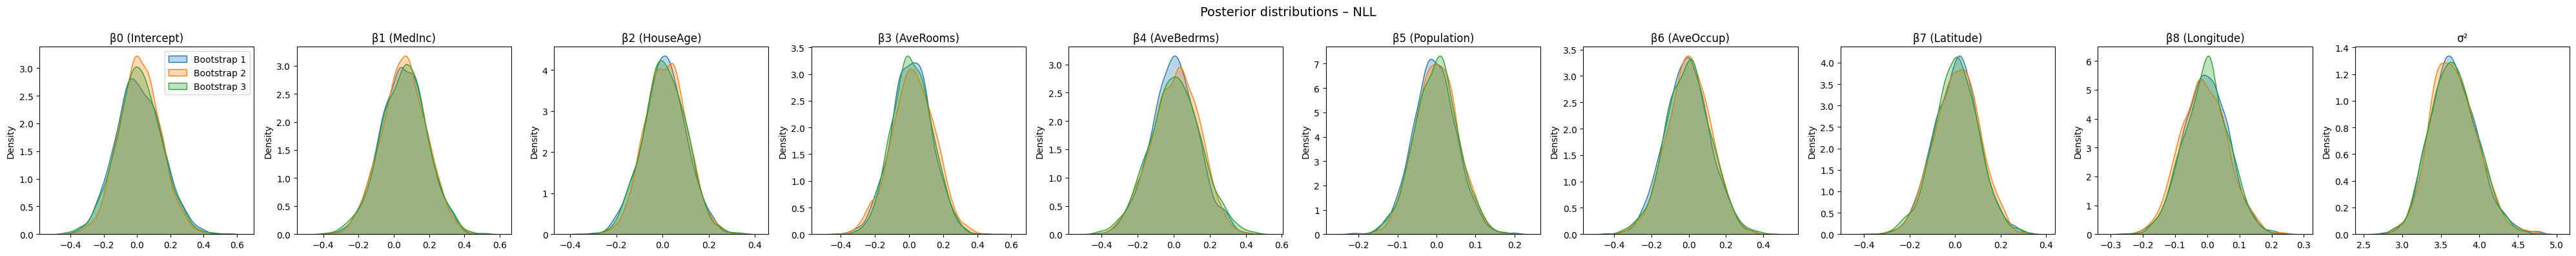

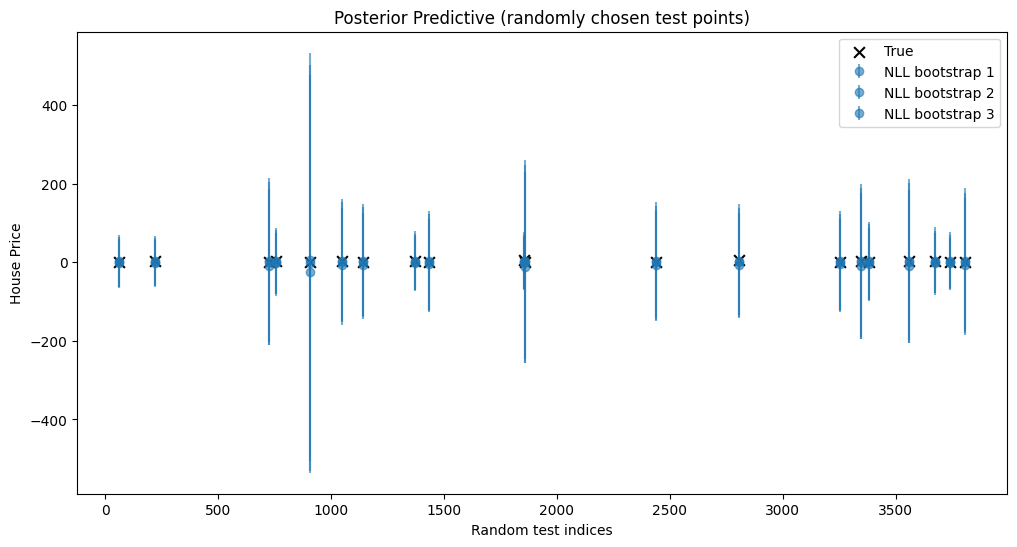


Predicted means for chosen points:
 Index    True Method  Bootstrap  Pred mean   Pred 2.5%  Pred 97.5%
    63 1.77600    NLL          1  -1.954337  -65.685822   58.093826
    63 1.77600    NLL          2   2.956054  -61.891739   70.621582
    63 1.77600    NLL          3   1.459189  -62.317127   64.900475
   221 3.34300    NLL          1  -1.664295  -62.315701   56.621082
   221 3.34300    NLL          2   2.990887  -59.360752   68.057365
   221 3.34300    NLL          3   1.497221  -58.586220   61.231174
   724 0.92600    NLL          1  -9.552871 -210.811996  187.659302
   724 0.92600    NLL          2   3.726322 -209.690109  214.949829
   724 0.92600    NLL          3   0.703218 -202.214127  204.249176
   758 2.73100    NLL          1  -2.772873  -86.000793   74.911133
   758 2.73100    NLL          2   3.043239  -81.358223   88.447380
   758 2.73100    NLL          3   1.396705  -80.702995   82.554199
   906 0.80900    NLL          1 -25.933805 -531.718384  476.017090
   906 0.809

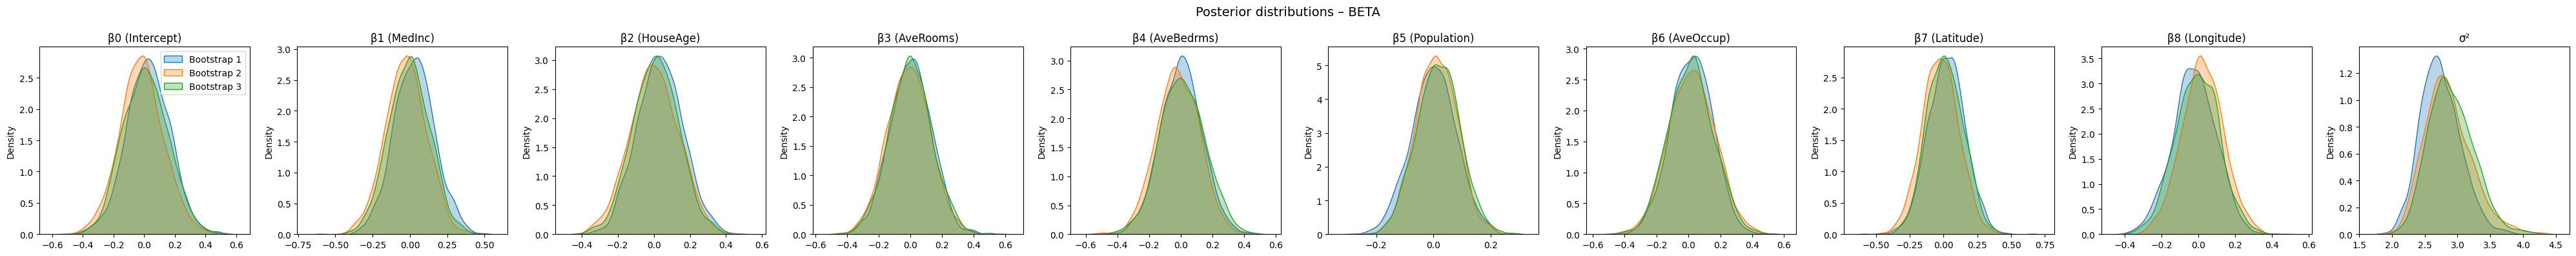

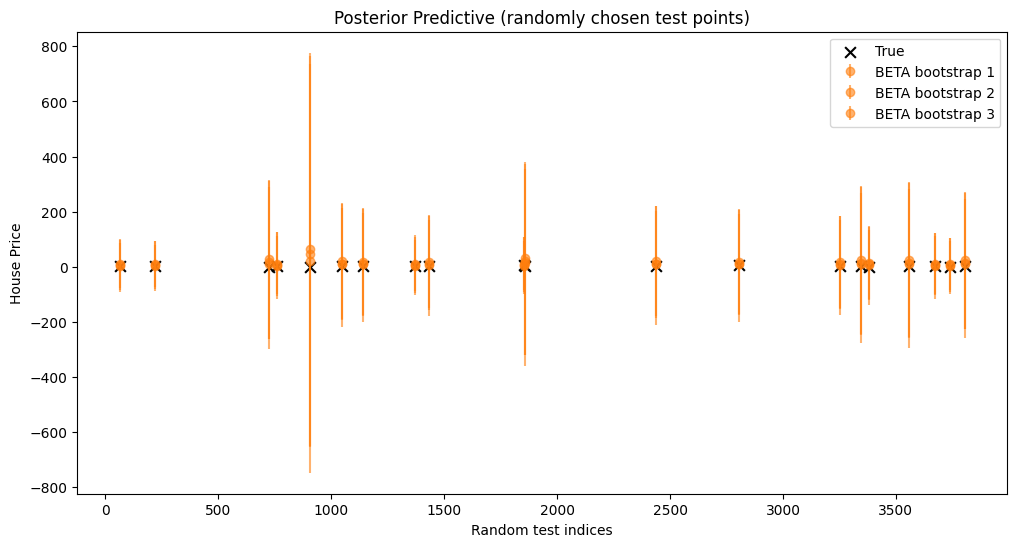


Predicted means for chosen points:
 Index    True Method  Bootstrap  Pred mean   Pred 2.5%  Pred 97.5%
    63 1.77600   BETA          1   7.169188  -91.316940  100.130867
    63 1.77600   BETA          2   2.039461  -84.618805   86.201218
    63 1.77600   BETA          3   9.326257  -76.304108   98.144913
   221 3.34300   BETA          1   7.542600  -87.064056   95.064140
   221 3.34300   BETA          2   1.617266  -79.585602   80.205536
   221 3.34300   BETA          3   8.995321  -74.315804   92.069412
   724 0.92600   BETA          1  11.755224 -296.883270  313.480896
   724 0.92600   BETA          2  15.708469 -261.767242  288.279175
   724 0.92600   BETA          3  26.871277 -261.140289  309.816223
   758 2.73100   BETA          1   7.696891 -118.480942  126.401199
   758 2.73100   BETA          2   3.843184 -106.296638  113.544418
   758 2.73100   BETA          3  11.596817  -99.971985  124.892059
   906 0.80900   BETA          1  21.930820 -747.078979  776.666748
   906 0.809

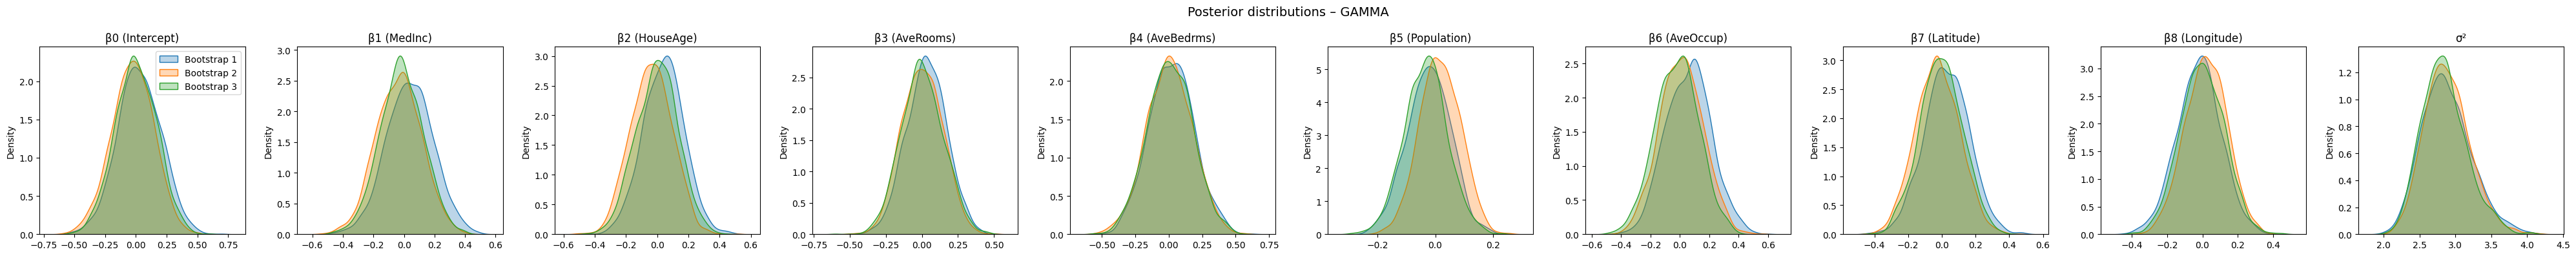

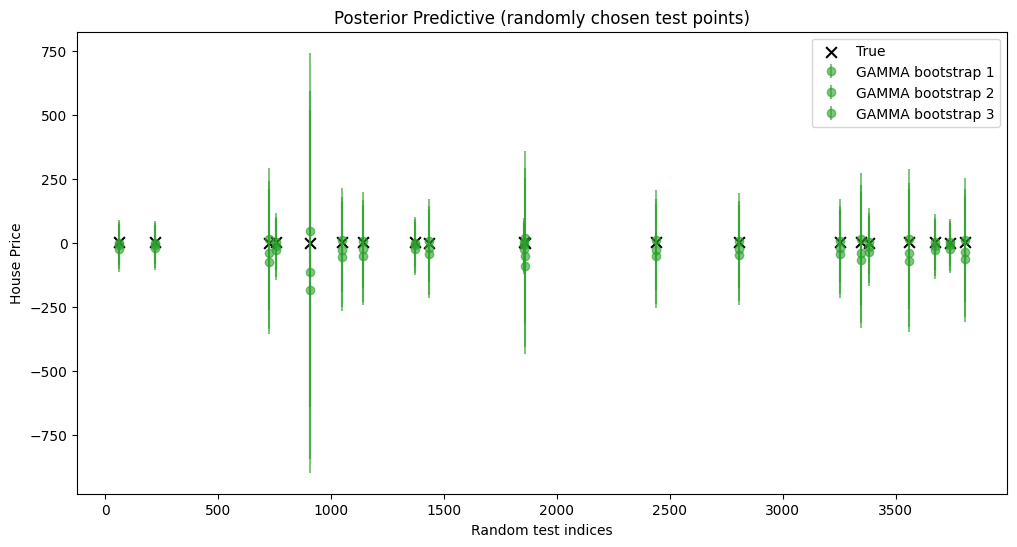


Predicted means for chosen points:
 Index    True Method  Bootstrap   Pred mean   Pred 2.5%  Pred 97.5%
    63 1.77600  GAMMA          1   -7.667407 -102.162292   80.903336
    63 1.77600  GAMMA          2    1.036296  -84.415947   88.926727
    63 1.77600  GAMMA          3  -22.100101 -111.699646   71.805077
   221 3.34300  GAMMA          1   -6.317582  -98.692421   79.262962
   221 3.34300  GAMMA          2    0.069807  -82.622704   84.345657
   221 3.34300  GAMMA          3  -20.697927 -105.278526   69.596565
   724 0.92600  GAMMA          1  -41.357853 -336.988770  239.663651
   724 0.92600  GAMMA          2   16.094141 -260.790192  293.985199
   724 0.92600  GAMMA          3  -73.416382 -356.341644  212.143219
   758 2.73100  GAMMA          1  -12.223928 -131.801132   99.595612
   758 2.73100  GAMMA          2    3.080826 -107.045578  115.328011
   758 2.73100  GAMMA          3  -28.948242 -143.552261   91.815964
   906 0.80900  GAMMA          1 -113.449768 -842.009460  591.37768

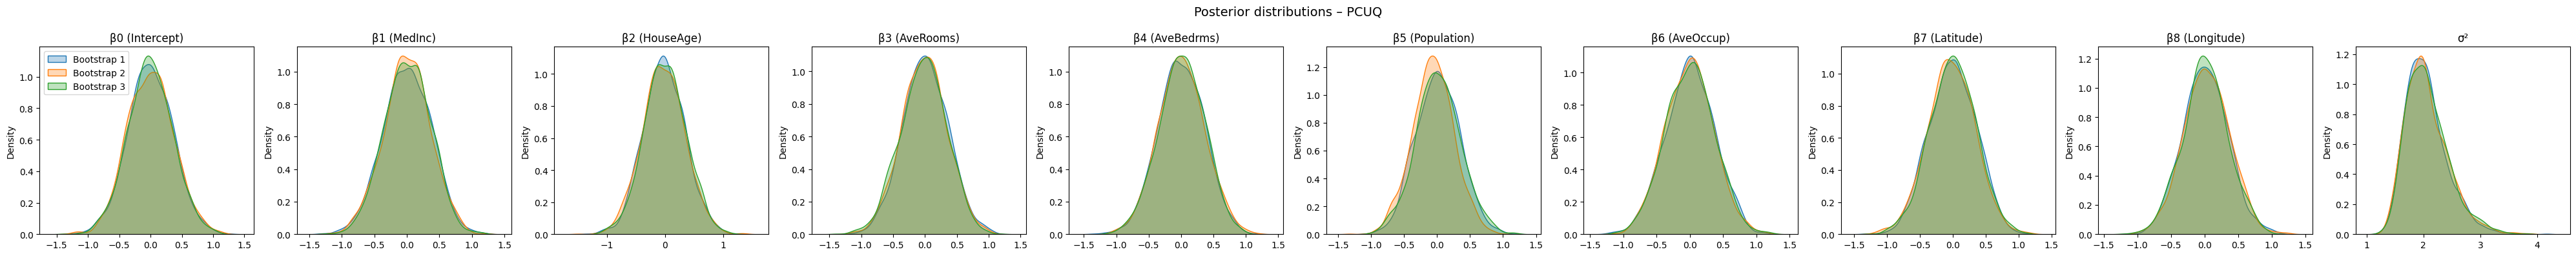

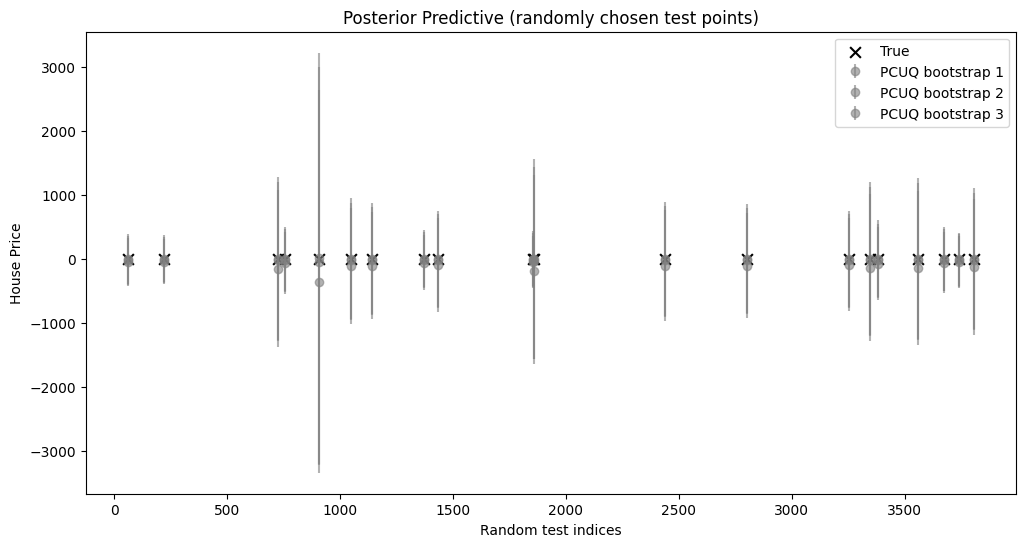


Predicted means for chosen points:
 Index    True Method  Bootstrap   Pred mean    Pred 2.5%  Pred 97.5%
    63 1.77600   PCUQ          1   -9.701235  -403.527313  365.835419
    63 1.77600   PCUQ          2  -49.931816  -420.985565  330.177460
    63 1.77600   PCUQ          3    1.803284  -387.821075  392.143860
   221 3.34300   PCUQ          1   -9.669412  -381.466278  346.079803
   221 3.34300   PCUQ          2  -47.880135  -395.937500  310.198303
   221 3.34300   PCUQ          3    1.686368  -363.931213  369.242798
   724 0.92600   PCUQ          1  -22.624260 -1281.299194 1202.037476
   724 0.92600   PCUQ          2 -150.264053 -1367.276001 1084.497681
   724 0.92600   PCUQ          3    5.422094 -1268.185913 1282.219727
   758 2.73100   PCUQ          1  -11.224211  -513.597595  471.714233
   758 2.73100   PCUQ          2  -63.181744  -547.586182  423.876526
   758 2.73100   PCUQ          3    2.326620  -504.692139  506.247772
   906 0.80900   PCUQ          1  -50.457462 -3225.082

In [129]:
# ------------------------------
# Train + plot immediately
# ------------------------------
methods = [
    ("nll",   {"beta": None, "gamma": None}),
    ("beta",  {"beta": 1.2,  "gamma": None}),
    ("gamma", {"beta": None, "gamma": 0.5}),
    ("pcuq",  {"beta": None, "gamma": None}),  
]

feature_names = ["Intercept"] + california.feature_names

for method, params in methods:
    q_list = []
    for j, (X_bs, y_bs) in enumerate(bootstraps, 1):
        print(f"\nTraining {method.upper()} on bootstrap {j}...")

        if method == "nll":
            qj = train_gvi_regression(
                X_bs, y_bs,
                loss_type="nll", divergence_type="kl",
                steps=STEPS, lr=LR, batch_size=BATCH_SIZE, mc_samples=MC_SAMPLES,
                prior_mean_beta=prior_mean_beta,
                prior_std_beta=prior_std_beta,
                prior_mean_logsig=prior_mean_logsig,
                prior_std_logsig=prior_std_logsig,
            )

        elif method == "beta":
            qj = train_gvi_regression(
                X_bs, y_bs,
                loss_type="beta", divergence_type="kl",
                beta=params["beta"],
                steps=STEPS, lr=LR, batch_size=BATCH_SIZE, mc_samples=MC_SAMPLES,
                prior_mean_beta=prior_mean_beta,
                prior_std_beta=prior_std_beta,
                prior_mean_logsig=prior_mean_logsig,
                prior_std_logsig=prior_std_logsig,
            )

        elif method == "gamma":
            qj = train_gvi_regression(
                X_bs, y_bs,
                loss_type="gamma", divergence_type="kl",
                gamma=params["gamma"],
                steps=STEPS, lr=LR, batch_size=BATCH_SIZE, mc_samples=MC_SAMPLES,
                prior_mean_beta=prior_mean_beta,
                prior_std_beta=prior_std_beta,
                prior_mean_logsig=prior_mean_logsig,
                prior_std_logsig=prior_std_logsig,
            )
        elif method == "pcuq":
            qj = train_pcuq_regression(
                X_bs, y_bs,
                steps=STEPS, lr=LR, mc_samples=MC_SAMPLES,
                lambda_reg=0.05, mmd_sigma=1.0,
                prior_mean_beta=prior_mean_beta,
                prior_std_beta=prior_std_beta,
                prior_mean_logsig=prior_mean_logsig,
                prior_std_logsig=prior_std_logsig,
            )


        else:
            raise RuntimeError("Unknown method")

        q_list.append(qj)
    plot_posteriors_all_betas({method: q_list}, num_samples=2000, feature_names=feature_names)
    plot_posterior_predictive_points(
        {method: q_list},
        X_test_np, y_test_np,
        num_points=20, num_samples=2000, log_scale=False
    )





In [130]:
import numpy as np
import pandas as pd

def reproducibility_check(results, X_test, y_test, num_points=20, lognormal=False):
    """
    Compare predictions across methods on randomly chosen test points,
    averaging across all bootstraps by pooling predictive draws.
    """
    rng = np.random.default_rng()   # no fixed seed → different every run
    idxs = rng.choice(len(y_test), size=num_points, replace=False)

    rows = []
    for i in idxs:
        row = {"Index": i}
        row["True"] = np.exp(y_test[i]) if lognormal else y_test[i]

        for method, q_list in results.items():
            all_samples = []
            for q in q_list:
                _, _, pred_samples = posterior_predictive_regression(
                    q, X_test[[i]], num_samples=500
                )

                # Assert expected shape: (1, num_samples)
                assert pred_samples.ndim == 2, f"{method} pred_samples has ndim={pred_samples.ndim}, expected 2"
                assert pred_samples.shape[0] == 1, f"{method} pred_samples shape={pred_samples.shape}, expected (1, S)"

                if lognormal:
                    pred_samples = np.exp(pred_samples)

                # Take the first (and only) row
                samples_1d = pred_samples[0, :]   # shape (S,)
                all_samples.append(samples_1d)

            # Concatenate across bootstraps
            all_samples = np.concatenate(all_samples, axis=0)

            # Compute pooled stats
            row[f"{method.upper()} mean"]   = all_samples.mean()
            row[f"{method.upper()} median"] = np.median(all_samples)
            row[f"{method.upper()} 2.5%"]   = np.percentile(all_samples, 2.5)
            row[f"{method.upper()} 97.5%"]  = np.percentile(all_samples, 97.5)

        rows.append(row)

    df = pd.DataFrame(rows).set_index("Index").sort_index()
    return df


# Example call
df_check = reproducibility_check(results, X_test_np, y_test_np, num_points=20, lognormal=False)
print("Reproducibility Check (log scale) with 95% Intervals")
print(df_check.to_string())

print(method, "pred_samples shape:", pred_samples.shape)
print("First 10 raw draws:", pred_samples[0, :10])


NameError: name 'results' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- pick indices ONCE and reuse ----------
rng = np.random.default_rng()                 # new random every run
idxs = rng.choice(len(y_test_np), size=20, replace=False)

NUM_SAMPLES = 500       # same for table & plot
Q_LOW, Q_HIGH = 2.5, 97.5
LOGSCALE = True         # you're on log(y)

# ---------- table: per-bootstrap AND pooled, on SAME idxs ----------
def reproducibility_check_with_boots(results, X_test, y_test, idxs,
                                     num_samples=NUM_SAMPLES, logscale=LOGSCALE,
                                     q_low=Q_LOW, q_high=Q_HIGH):
    rows = []
    for i in idxs:
        row = {"Index": int(i),
               "True": float(y_test[i] if logscale else np.exp(y_test[i]))}

        for method, q_list in results.items():
            pooled = []
            # per-bootstrap (to match plot-per-bootstrap)
            for b, q in enumerate(q_list, 1):
                _, _, pred = posterior_predictive_regression(q, X_test[[i]], num_samples=num_samples)
                assert pred.ndim == 2 and pred.shape[0] == 1
                if not logscale:
                    pred = np.exp(pred)
                s = pred[0, :]  # (S,)

                tag = f"{method.upper()}_b{b}"
                row[f"{tag} mean"]   = float(s.mean())
                row[f"{tag} median"] = float(np.median(s))
                row[f"{tag} {q_low}%"]  = float(np.percentile(s, q_low))
                row[f"{tag} {q_high}%"] = float(np.percentile(s, q_high))
                pooled.append(s)

            pooled = np.concatenate(pooled, axis=0)  # (B*S,)
            tag = f"{method.upper()} pooled"
            row[f"{tag} mean"]   = float(pooled.mean())
            row[f"{tag} median"] = float(np.median(pooled))
            row[f"{tag} {q_low}%"]  = float(np.percentile(pooled, q_low))
            row[f"{tag} {q_high}%"] = float(np.percentile(pooled, q_high))

        rows.append(row)

    return pd.DataFrame(rows).set_index("Index").sort_index()

df_check = reproducibility_check_with_boots(results, X_test_np, y_test_np, idxs)
print(df_check.to_string())

# ---------- plot: choose same aggregation as table ----------
def plot_points_per_bootstrap(results, X_test, y_test, idxs,
                              num_samples=NUM_SAMPLES, logscale=LOGSCALE,
                              q_low=Q_LOW, q_high=Q_HIGH):
    fig, ax = plt.subplots(figsize=(12,6))
    y_plot = y_test if logscale else np.exp(y_test)
    ax.scatter(idxs, y_plot[idxs], color="black", marker="x", s=60, label="True")

    for method, q_list in results.items():
        for b, q in enumerate(q_list, 1):
            _, _, pred = posterior_predictive_regression(q, X_test[idxs], num_samples=num_samples)
            if not logscale:
                pred = np.exp(pred)

            mean  = pred.mean(axis=1)
            low   = np.percentile(pred, q_low, axis=1)
            high  = np.percentile(pred, q_high, axis=1)

            yerr = np.vstack([mean - low, high - mean])
            ax.errorbar(idxs, mean, yerr=yerr, fmt="o", alpha=0.75, label=f"{method.upper()} b{b}")

    ax.set_xlabel("Random test indices")
    ax.set_ylabel("log(House Price)" if logscale else "House Price")
    ax.set_title("Posterior Predictive (same points, per-bootstrap, same quantiles/MC)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return {"idxs": idxs, "means_per_boot": mean}  # minimal return to allow comparisons

def plot_points_pooled(results, X_test, y_test, idxs,
                       num_samples=NUM_SAMPLES, logscale=LOGSCALE,
                       q_low=Q_LOW, q_high=Q_HIGH):
    fig, ax = plt.subplots(figsize=(12,6))
    y_plot = y_test if logscale else np.exp(y_test)
    ax.scatter(idxs, y_plot[idxs], color="black", marker="x", s=60, label="True")

    for method, q_list in results.items():
        pooled_means, pooled_lows, pooled_highs = [], [], []
        for i in idxs:
            pooled = []
            for q in q_list:
                _, _, pred = posterior_predictive_regression(q, X_test[[i]], num_samples=num_samples)
                if not logscale:
                    pred = np.exp(pred)
                pooled.append(pred[0, :])
            pooled = np.concatenate(pooled, axis=0)
            pooled_means.append(pooled.mean())
            pooled_lows.append(np.percentile(pooled, q_low))
            pooled_highs.append(np.percentile(pooled, q_high))

        pm = np.array(pooled_means)
        pl = np.array(pooled_lows)
        ph = np.array(pooled_highs)
        yerr = np.vstack([pm - pl, ph - pm])
        ax.errorbar(idxs, pm, yerr=yerr, fmt="o", alpha=0.9, label=f"{method.upper()} pooled")

    ax.set_xlabel("Random test indices")
    ax.set_ylabel("log(House Price)" if logscale else "House Price")
    ax.set_title("Posterior Predictive (same points, pooled across bootstraps)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return {"idxs": idxs, "pooled_means": pm, "pooled_lows": pl, "pooled_highs": ph}


NameError: name 'results' is not defined